# Capstone Project

## Step 1: Data Collection, Cleaning, Preprocessing

In [1]:
import matplotlib.pyplot as plt
from datasets import load_dataset
import pandas as pd
import numpy as np


dataset = load_dataset("BrotherTony/employee-burnout-turnover-prediction-800k")

## Overview of variables from HuggingFace

- Core Identity
    - employee_id Unique synthetic identifier
    - role Job title (300+ varieties)
    - job_level Entry | Mid | Senior | Manager | Lead
    - department Business unit (38 departments)
    - tenure_months Time with company (1-357 months)
- Compensation
    - salary Annual USD ($27K-$384K range)
    - Performance Indicators
    - performance_score Normalized 0-1 rating
    - project_completion_rate Delivery success metric
    - goal_achievement_rate Objective completion
    - role_complexity_score Job difficulty rating
    - career_progression_score Growth trajectory
- Wellbeing & Engagement
    - satisfaction_score Employee happiness (0-1)
    - workload_score Workload burden indicator
    - stress_level Stress assessment (0-1)
    - burnout_risk Burnout probability (0-1)
    - training_participation L&D engagement
    - Collaboration & Communication
    - team_sentiment Team morale (0-1)
    - email_sentiment Email tone analysis
    - slack_activity Chat platform usage
    - meeting_participation Meeting engagement
    - collaboration_score Teamwork rating
    - communication_patterns Persona-based style
- Skills & Competencies
    - technical_skills Array of tech skills (4-9 per employee)
    - soft_skills Array of soft skills (3-7 per employee)
- Attrition & Risk
    - left_company Boolean exit flag
    - turnover_reason Exit category (if applicable)
    - turnover_probability_generated ML-predicted churn risk
    - risk_factors_summary Low | Medium | High | Severe risk
- Behavioral Profiling
    - persona_name 12 archetypes:
        -   OverachievingSprinter
        -   BurntOutStar
        -   QuietAchiever
        -   NewEnthusiast
        -   StrugglingLearner
        -   SteadyEddy
        -   ChangeResistor
        -   SeasonedExpert
        -   SocialCatalyst
        -   9-to-5Clockwatcher
        -   AmbitiousClimber
        -   CorporateNavigator (Persona Names are A.I. generated)
- Qualitative Data
    - recent_feedback Anonymized employee comments (1000+ unique snippets)
    - overtime_hours Extra hours logged (0-74 range)

In [2]:
df = dataset["train"].to_pandas()

df.shape

(849999, 31)

In [3]:
df.head()

,employee_id,role,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,...,goal_achievement_rate,stress_level,burnout_risk,left_company,turnover_reason,risk_factors_summary,turnover_probability_generated,persona_name,role_complexity_score,career_progression_score
0,SYN_00000000,,Mid,Research & Development,169,79704.579059,0.632482,0.623746,0.758117,0.662335,...,0.632482,0.908992,0.866643,False,Not Applicable,Severe Burnout Risk,0.290979,ChangeResistor,0.2,1.000000
1,SYN_00000001,Customer Success Manager,Manager,Research & Development,54,29694.288831,0.538587,0.982556,0.788416,0.934661,...,0.538587,0.363321,0.218996,False,Not Applicable,Low Risk,0.156002,NewEnthusiast,0.2,1.000000
2,SYN_00000002,Administrative Assistant,Entry,HR,1,62208.470185,0.624656,0.767200,0.697617,0.888559,...,0.624656,0.664378,0.541531,True,Personal / Relocation,Low Risk,0.233897,NewEnthusiast,0.2,0.836495
3,SYN_00000003,Senior Manager,Manager,Research & Development,31,236066.567114,0.959320,0.185888,0.493143,0.732189,...,0.959320,1.000000,1.000000,False,Not Applicable,Severe Burnout Risk,0.351682,OverachievingSprinter,0.2,1.000000
4,SYN_00000004,Anonymous Employee,Mid,Research & Development,131,37306.328156,0.677305,0.566706,0.567230,0.817545,...,0.677305,0.723049,0.614825,False,Not Applicable,Low Risk,0.272910,SeasonedExpert,0.2,1.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 849999 entries, 0 to 849998
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   employee_id                     849999 non-null  str    
 1   role                            849999 non-null  str    
 2   job_level                       849999 non-null  str    
 3   department                      849999 non-null  str    
 4   tenure_months                   849999 non-null  int64  
 5   salary                          849999 non-null  float64
 6   performance_score               849999 non-null  float64
 7   satisfaction_score              849999 non-null  float64
 8   workload_score                  849999 non-null  float64
 9   team_sentiment                  849999 non-null  float64
 10  recent_feedback                 849999 non-null  str    
 11  communication_patterns          849999 non-null  str    
 12  project_completion_rate    

In [5]:
df.isnull().sum()

employee_id                       0
role                              0
job_level                         0
department                        0
tenure_months                     0
salary                            0
performance_score                 0
satisfaction_score                0
workload_score                    0
team_sentiment                    0
recent_feedback                   0
communication_patterns            0
project_completion_rate           0
overtime_hours                    0
training_participation            0
collaboration_score               0
technical_skills                  0
soft_skills                       0
email_sentiment                   0
slack_activity                    0
meeting_participation             0
goal_achievement_rate             0
stress_level                      0
burnout_risk                      0
left_company                      0
turnover_reason                   0
risk_factors_summary              0
turnover_probability_generat

### Initial Overview
Row Count: 849,999
Column Count: 31
NA Values: 0

In [6]:
df.dtypes.value_counts()

float64    18
str         9
object      2
int64       1
bool        1
Name: count, dtype: int64

In [7]:
df["left_company"].value_counts()

left_company
False    607473
True     242526
Name: count, dtype: int64

In [8]:
df["left_company"].value_counts(normalize=True)

left_company
False    0.714675
True     0.285325
Name: proportion, dtype: float64

### Target Variable
The target variable has a mild split. I belive the route I will take is to use train_test_splits stratify y to just be sure the proportions in the train and test splits are equal for the target variable. If later I run into issues with poor model results I may reevaluate.

In [9]:
df.dtypes

employee_id                           str
role                                  str
job_level                             str
department                            str
tenure_months                       int64
salary                            float64
performance_score                 float64
satisfaction_score                float64
workload_score                    float64
team_sentiment                    float64
recent_feedback                       str
communication_patterns                str
project_completion_rate           float64
overtime_hours                    float64
training_participation            float64
collaboration_score               float64
technical_skills                   object
soft_skills                        object
email_sentiment                   float64
slack_activity                    float64
meeting_participation             float64
goal_achievement_rate             float64
stress_level                      float64
burnout_risk                      

In [10]:
df.head()

,employee_id,role,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,...,goal_achievement_rate,stress_level,burnout_risk,left_company,turnover_reason,risk_factors_summary,turnover_probability_generated,persona_name,role_complexity_score,career_progression_score
0,SYN_00000000,,Mid,Research & Development,169,79704.579059,0.632482,0.623746,0.758117,0.662335,...,0.632482,0.908992,0.866643,False,Not Applicable,Severe Burnout Risk,0.290979,ChangeResistor,0.2,1.000000
1,SYN_00000001,Customer Success Manager,Manager,Research & Development,54,29694.288831,0.538587,0.982556,0.788416,0.934661,...,0.538587,0.363321,0.218996,False,Not Applicable,Low Risk,0.156002,NewEnthusiast,0.2,1.000000
2,SYN_00000002,Administrative Assistant,Entry,HR,1,62208.470185,0.624656,0.767200,0.697617,0.888559,...,0.624656,0.664378,0.541531,True,Personal / Relocation,Low Risk,0.233897,NewEnthusiast,0.2,0.836495
3,SYN_00000003,Senior Manager,Manager,Research & Development,31,236066.567114,0.959320,0.185888,0.493143,0.732189,...,0.959320,1.000000,1.000000,False,Not Applicable,Severe Burnout Risk,0.351682,OverachievingSprinter,0.2,1.000000
4,SYN_00000004,Anonymous Employee,Mid,Research & Development,131,37306.328156,0.677305,0.566706,0.567230,0.817545,...,0.677305,0.723049,0.614825,False,Not Applicable,Low Risk,0.272910,SeasonedExpert,0.2,1.000000


In [11]:
df["job_level"].unique()

<ArrowStringArray>
['Mid', 'Manager', 'Entry', 'Senior', 'Lead']
Length: 5, dtype: str

In [12]:
df["role"].unique()

<ArrowStringArray>
[                        ' ', ' Customer Success Manager',
 ' Administrative Assistant',           ' Senior Manager',
       ' Anonymous Employee',  ' Senior Business Analyst',
                    ' Sales',           ' Support Worker',
         ' Customer Advisor',        ' Senior Consultant',
 ...
     ' Technical Consultant',                 ' Fry Cook',
                ' Architect',               ' Technician',
       ' IT Project Manager',                   ' Genius',
             ' Risk Analyst',                   ' Driver',
              ' Tax Analyst',   ' Senior Account Manager']
Length: 300, dtype: str

In [13]:
df["role"].value_counts()

role
 Anonymous Employee                      224117
                                         109047
Current Employee - Anonymous Employee     21989
 Manager                                  20440
 Consultant                               17308
                                          ...  
 Technical Consultant                       373
 Operations Specialist                      369
 Security Officer                           353
 Actuarial Analyst                          350
 Driver                                     346
Name: count, Length: 300, dtype: int64

Removal of role column as well because majority are NA values

## Variable Reduction
- employee_id - Employee Indicator Number
- burnout_risk - Unreasonable to have
- turnover_reason - Clear leakage, if there is a reason the model will know the employee left
- risk_factors_summary - Categorizes into a risk factor summary, this is something we would want to create on our own
- turnover_probability_generated - Again, this is something we are trying to compute with the model
- persona_name - Again, a persona might be something we create from analysis of the data
- communication_patters - This again seemed to be a summary gained from previous analysis. I believe I can create more believable ones simply from doing some analysis on things like recent_feedback
- role - Many unique roles, much of the data is captured in job_level and department variables (Example: Role (Senior Manager) Job_level (Manager) department (R&D)

In [14]:
df_clean = df.drop(["employee_id", "burnout_risk", "turnover_reason", "risk_factors_summary", "turnover_probability_generated", "persona_name","communication_patterns", "role"], axis=1)
df_clean.head()

,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,recent_feedback,project_completion_rate,...,technical_skills,soft_skills,email_sentiment,slack_activity,meeting_participation,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score
0,Mid,Research & Development,169,79704.579059,0.632482,0.623746,0.758117,0.662335,Close to home and good shift time given Slow i...,0.524187,...,"[REST APIs, Python (Pandas, NumPy, SciPy), Lin...","[Communication, Creativity, Teamwork, Conflict...",0.632891,0.492131,0.492131,0.632482,0.908992,False,0.2,1.000000
1,Manager,Research & Development,54,29694.288831,0.538587,0.982556,0.788416,0.934661,HSBC Software Development Pune India Review Gr...,0.558206,...,"[Network Security, GCP, dbt, Express.js, Docke...","[Conflict Resolution, Problem Solving, Creativ...",1.000000,0.981394,0.981394,0.538587,0.363321,False,0.2,1.000000
2,Entry,HR,1,62208.470185,0.624656,0.767200,0.697617,0.888559,Great opportunity for growth if you drink the ...,0.566849,...,"[Node.js, dbt, CI/CD Pipelines, Angular, Ruby ...","[Problem Solving, Critical Thinking, Teamwork,...",0.758005,0.701138,0.701138,0.624656,0.664378,True,0.2,0.836495
3,Manager,Research & Development,31,236066.567114,0.959320,0.185888,0.493143,0.732189,Fabulous people and broad opportunities The ch...,0.767456,...,"[Ruby on Rails, GraphQL, Python (Django, Flask...","[Emotional Intelligence, Leadership, Conflict ...",0.202517,0.339626,0.339626,0.959320,1.000000,False,0.2,1.000000
4,Mid,Research & Development,131,37306.328156,0.677305,0.566706,0.567230,0.817545,"The harder you work, the faster you climb. I w...",0.597235,...,"[Vue.js, XGBoost, ETL/ELT Pipelines, Linux/Uni...","[Critical Thinking, Communication, Creativity,...",0.559722,0.565582,0.565582,0.677305,0.723049,False,0.2,1.000000


In [15]:
df_clean.columns

Index(['job_level', 'department', 'tenure_months', 'salary',
       'performance_score', 'satisfaction_score', 'workload_score',
       'team_sentiment', 'recent_feedback', 'project_completion_rate',
       'overtime_hours', 'training_participation', 'collaboration_score',
       'technical_skills', 'soft_skills', 'email_sentiment', 'slack_activity',
       'meeting_participation', 'goal_achievement_rate', 'stress_level',
       'left_company', 'role_complexity_score', 'career_progression_score'],
      dtype='str')

In [16]:
df_clean.dtypes

job_level                       str
department                      str
tenure_months                 int64
salary                      float64
performance_score           float64
satisfaction_score          float64
workload_score              float64
team_sentiment              float64
recent_feedback                 str
project_completion_rate     float64
overtime_hours              float64
training_participation      float64
collaboration_score         float64
technical_skills             object
soft_skills                  object
email_sentiment             float64
slack_activity              float64
meeting_participation       float64
goal_achievement_rate       float64
stress_level                float64
left_company                   bool
role_complexity_score       float64
career_progression_score    float64
dtype: object

## Variable Encoding

In [17]:
df_clean.select_dtypes(exclude="number").columns

Index(['job_level', 'department', 'recent_feedback', 'technical_skills',
       'soft_skills', 'left_company'],
      dtype='str')

In [18]:
encoding_table = pd.DataFrame({
    "Variable": [
        "department",
        "job_level",
        "recent_feedback",
        "technical_skills",
        "soft_skills"
    ],
    "Encoding": [
        "One Hot Encode",
        "Ordinal Encode",
        "Feature Engineer Later",
        "Feature Engineer Later",
        "Feature Engineer Later",
    ]
})

print(encoding_table)

           Variable                Encoding
0        department          One Hot Encode
1         job_level          Ordinal Encode
2   recent_feedback  Feature Engineer Later
3  technical_skills  Feature Engineer Later
4       soft_skills  Feature Engineer Later


In [19]:
df_clean["department"].unique()

<ArrowStringArray>
['Research & Development',                     'HR',                  'Dairy',
            'Procurement',                  'Meats',      'Sales & Marketing',
             'Technology',             'Operations',                  'Sales',
                  'Legal',        'Processed Foods',                    'R&D',
              'Analytics',                'Produce',       'Customer Service',
      'Production       ',                 'Bakery',                'Finance',
        'Human Resources',          'Admin Offices',                    'nan',
       'Store Management',          'HR Technology',                  'IT/IS',
   'Software Engineering',                  'Audit',   'Accounts Receiveable',
        'Labor Relations',               'Training',             'Investment',
             'Accounting',       'Accounts Payable',           'Compensation',
 'Information Technology',            'Recruitment',              'Executive',
       'Executive Office',       

In [20]:
df_clean["job_level"].unique()

<ArrowStringArray>
['Mid', 'Manager', 'Entry', 'Senior', 'Lead']
Length: 5, dtype: str

Job level looks to be in great shape. I will clean up department as there are issues here.

In [21]:
df_clean["department"].value_counts()

department
Sales & Marketing         155390
Research & Development    101963
Operations                101176
Technology                 64037
Procurement                63979
Analytics                  49011
Sales                      48980
Customer Service           36774
Meats                      32376
Dairy                      32370
Bakery                     30759
Produce                    24426
HR                         23018
Finance                    23011
Processed Foods            15664
Production                 13326
Legal                       9400
R&D                         9228
Human Resources             6569
IT/IS                       2145
nan                          983
Store Management             871
Software Engineering         454
Admin Offices                420
Accounting                   370
Accounts Receiveable         360
Training                     336
Recruitment                  323
Audit                        320
Accounts Payable             317

In [22]:
# Clean and Combine departments that are either similar or the same

df_clean["department"] = df_clean["department"].str.strip()
df_clean["department"] = df_clean["department"].replace({
    "Human Resources": "HR",
    "HR Technology": "HR",
    "Research & Development": "R&D",
    "Technology": "IT",
    "IT/IS": "IT",
    "Software Engineering": "IT",
    "Information Technology": "IT",
    "Accounts Receiveable": "Accounting",
    "Accounts Payable": "Accounting",
    "nan": "Unknown",
    "Executive Office": "Executive",
    "Dairy": "Grocery",
    "Meats": "Grocery",
    "Bakery": "Grocery",
    "Processed Foods": "Grocery",
    "Produce": "Grocery",
    "Compensation": "HR",
    "Recruitment": "HR",
    "Employee Records": "HR",
    "Audit": "Accounting",
    "Labor Relations": "HR",
    "Training": "HR",
    "Sales": "Sales & Marketing",
    "Investment": "Finance",
    "Admin Offices": "Executive"
})

In [23]:
df_clean["department"].unique()

<ArrowStringArray>
[              'R&D',                'HR',           'Grocery',
       'Procurement', 'Sales & Marketing',                'IT',
        'Operations',             'Legal',         'Analytics',
  'Customer Service',        'Production',           'Finance',
         'Executive',           'Unknown',  'Store Management',
        'Accounting']
Length: 16, dtype: str

In [24]:
df_clean["department"].value_counts()

department
Sales & Marketing    204370
Grocery              135595
R&D                  111191
Operations           101176
IT                    66856
Procurement           63979
Analytics             49011
Customer Service      36774
HR                    31225
Finance               23196
Production            13326
Legal                  9400
Accounting             1367
Unknown                 983
Store Management        871
Executive               679
Name: count, dtype: int64

## Numeric Data Overview

In [25]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure_months,849999.0,70.380999,50.177033,1.000000,30.000000,67.000000,105.000000,357.000000
salary,849999.0,84563.069751,47444.308564,27190.569289,41006.776951,78178.525918,116146.639606,384330.428656
performance_score,849999.0,0.692027,0.183911,0.074113,0.571340,0.699235,0.825585,1.000000
satisfaction_score,849999.0,0.581941,0.276268,0.050000,0.367016,0.583188,0.813912,1.000000
workload_score,849999.0,0.599490,0.200038,0.006741,0.455657,0.613744,0.756693,0.999615
team_sentiment,849999.0,0.666848,0.178232,0.019774,0.545729,0.686320,0.806540,0.999956
project_completion_rate,849999.0,0.595412,0.161173,0.059290,0.490179,0.609499,0.716149,1.000000
overtime_hours,849999.0,3.132903,6.094207,0.000000,0.000000,0.000000,4.161240,73.953574
training_participation,849999.0,0.279344,0.221602,0.000079,0.103691,0.223123,0.400716,1.000000
collaboration_score,849999.0,0.473380,0.184961,0.008674,0.332366,0.457102,0.600885,1.000000


Text(0.5, 1.0, 'Salary')

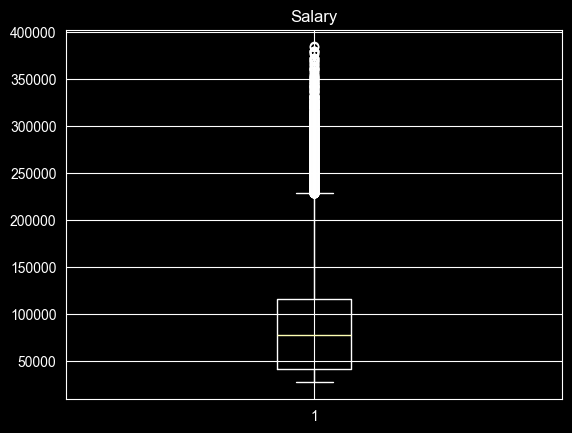

In [26]:
plt.boxplot(df_clean["salary"])
plt.title("Salary")

Text(0.5, 1.0, 'Overtime')

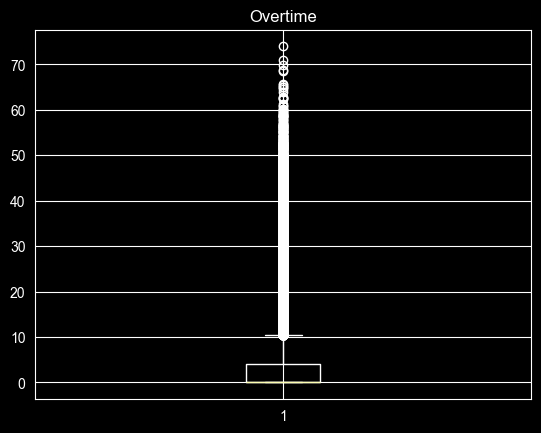

In [27]:
plt.boxplot(df_clean["overtime_hours"])
plt.title("Overtime")

In [28]:
df_clean["overtime_hours"].quantile([0.95,0.99,0.995,0.999])

0.950    16.469986
0.990    26.415813
0.995    30.480404
0.999    39.678071
Name: overtime_hours, dtype: float64

In [29]:
# Overtime IQR
Q1 = df_clean["overtime_hours"].quantile(0.25)
Q3 = df_clean["overtime_hours"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean["overtime_hours"] > upper) | (df_clean["overtime_hours"] < lower)]
outliers

,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,recent_feedback,project_completion_rate,...,technical_skills,soft_skills,email_sentiment,slack_activity,meeting_participation,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score
15,Mid,Operations,106,30555.117342,1.000000,0.965974,0.368575,0.657452,Excellent Starting Point and Career Experience...,0.873715,...,"[Python (Pandas, NumPy, SciPy), Go, Linux/Unix...","[Creativity, Teamwork, Mentorship, Leadership,...",1.000000,0.657452,0.657452,1.000000,0.631425,False,0.2,1.000000
21,Mid,IT,52,75126.049280,0.944274,0.703804,0.333019,0.398434,Great office with great people in Old Town Sco...,0.765003,...,"[Network Security, Kubernetes, Data Modeling, ...","[Teamwork, Time Management, Creativity]",0.714901,0.318919,0.318919,0.944274,0.952080,False,0.2,0.988804
42,Mid,IT,115,95574.323456,0.800380,0.743965,0.286216,0.646333,Love the technology and the peers! An FMCG SCH...,0.640304,...,"[Computer Vision, Express.js, dbt, XGBoost, No...","[Creativity, Problem Solving, Time Management,...",0.719377,0.519369,0.519369,0.800380,1.000000,False,0.2,1.000000
45,Mid,Customer Service,1,48480.314304,0.513699,0.480554,0.292526,0.761085,great company to work Surrounded by smart peop...,0.410959,...,"[Apache Kafka, Ansible, Svelte, Webpack, CSS3]","[Emotional Intelligence, Creativity, Time Mana...",0.480579,0.484359,0.484359,0.513699,1.000000,True,0.2,0.341016
62,Entry,Grocery,50,114170.000218,1.000000,0.987024,0.338931,0.478504,its a wage so it’s manageable Nothing beats wh...,0.800000,...,"[XGBoost, Machine Learning Theory, Computer Vi...","[Mentorship, Adaptability, Communication, Time...",1.000000,0.454579,0.454579,1.000000,1.000000,False,0.2,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
849924,Mid,Grocery,146,59082.576768,0.602783,0.996292,0.414990,0.733356,"Good culture, no any issues good brand to sell...",0.565224,...,"[A/B Testing, Express.js, Python (Django, Flas...","[Leadership, Problem Solving, Time Management,...",1.000000,0.733356,0.733356,0.602783,0.585010,True,0.2,1.000000
849925,Entry,Operations,108,173552.201167,1.000000,0.408630,0.367552,0.898103,a company that used to be inspirational The op...,0.800000,...,"[ETL/ELT Pipelines, Java (Spring Boot), dbt, G...","[Adaptability, Mentorship, Critical Thinking, ...",0.393118,0.490744,0.490744,1.000000,1.000000,False,0.2,1.000000
849965,Mid,Operations,52,99627.114862,0.729942,0.997828,0.393323,0.579257,It is one of the leading companies in the worl...,0.682618,...,"[Docker, Python (Pandas, NumPy, SciPy), Networ...","[Problem Solving, Emotional Intelligence, Conf...",1.000000,0.579257,0.579257,0.729942,0.506677,True,0.2,0.781638
849979,Mid,Sales & Marketing,13,42373.340322,0.410077,0.402426,0.449570,0.512177,Very smart and wonderful people. no Apple empl...,0.328062,...,"[Machine Learning Theory, CI/CD Pipelines, Azu...","[Creativity, Leadership, Communication, Adapta...",0.414506,0.302263,0.302263,0.410077,1.000000,True,0.2,0.399205


In [30]:
upper

np.float64(10.4030998235)

In [31]:
# Salary IQR
Q1 = df_clean["salary"].quantile(0.25)
Q3 = df_clean["salary"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean["salary"] > upper) | (df_clean["salary"] < lower)]
outliers

,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,recent_feedback,project_completion_rate,...,technical_skills,soft_skills,email_sentiment,slack_activity,meeting_participation,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score
3,Manager,R&D,31,236066.567114,0.959320,0.185888,0.493143,0.732189,Fabulous people and broad opportunities The ch...,0.767456,...,"[Ruby on Rails, GraphQL, Python (Django, Flask...","[Emotional Intelligence, Leadership, Conflict ...",0.202517,0.339626,0.339626,0.959320,1.000000,False,0.2,1.000000
192,Lead,Sales & Marketing,134,233167.130758,0.299067,0.334554,0.658352,0.412823,You are constantly spied on and talked about b...,0.239254,...,"[Kubernetes, REST APIs, Go, Ansible, Angular, ...","[Communication, Problem Solving, Leadership, C...",0.322961,0.238893,0.238893,0.299067,1.000000,True,0.2,1.000000
223,Mid,R&D,71,230611.714542,0.590959,0.309930,0.709765,0.856910,mid management is extremely inexperienced and ...,0.472767,...,"[A/B Testing, REST APIs, React, Site Reliabili...","[Communication, Critical Thinking, Leadership,...",0.291633,0.432005,0.432005,0.590959,1.000000,True,0.2,0.731313
571,Entry,HR,88,241590.359988,0.898342,0.359893,0.720298,0.567561,its was very good working there in had like it...,0.731480,...,"[C# (.NET), Linux/Unix Administration, Airflow...","[Conflict Resolution, Leadership, Creativity, ...",0.343733,0.291489,0.291489,0.898342,0.935969,False,0.2,1.000000
590,Mid,Grocery,98,237712.166249,0.939641,0.121542,0.554301,0.737120,Great place for students No clear set up and g...,0.751713,...,"[JavaScript (ESNext), HTML5, Computer Vision, ...","[Communication, Emotional Intelligence, Adapta...",0.131678,0.289080,0.289080,0.939641,1.000000,False,0.2,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
849035,Manager,Sales & Marketing,41,247870.130985,0.222508,0.872832,0.528911,0.920150,Rotational Team Manager There were some good m...,0.216501,...,"[Python (Django, Flask, FastAPI), Machine Lear...","[Creativity, Leadership, Mentorship]",0.854228,0.867570,0.867570,0.222508,0.807524,False,0.2,0.968968
849131,Mid,Sales & Marketing,47,251125.331455,0.475477,0.168932,0.551889,0.567707,Great Place to Work!! - salary\r\n- work/life ...,0.380381,...,"[Computer Vision, Svelte, Rust, Site Reliabili...","[Creativity, Emotional Intelligence, Mentorshi...",0.169022,0.237481,0.237481,0.475477,1.000000,True,0.2,0.953572
849137,Mid,Grocery,98,232222.528088,0.678457,0.402646,0.680768,0.871581,"SAP Labs outlook, Palo Alto Limited postdoc op...",0.542766,...,"[Machine Learning Theory, Network Security, Py...","[Communication, Time Management, Adaptability,...",0.416303,0.515464,0.515464,0.678457,1.000000,False,0.2,0.887562
849339,Mid,Analytics,67,248938.920548,0.479858,0.347292,0.655568,0.457864,"Cutting Edge Tech, Fast Paced As organization ...",0.383886,...,"[Angular, Terraform, Site Reliability Engineer...","[Critical Thinking, Mentorship, Communication,...",0.349639,0.249420,0.249420,0.479858,1.000000,False,0.2,0.839096


In [32]:
# tenure IQR
Q1 = df_clean['tenure_months'].quantile(0.25)
Q3 = df_clean['tenure_months'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['tenure_months'] > upper) | (df_clean['tenure_months'] < lower)]
outliers

,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,recent_feedback,project_completion_rate,...,technical_skills,soft_skills,email_sentiment,slack_activity,meeting_participation,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score
172,Entry,Sales & Marketing,221,122204.588278,0.631789,0.219018,0.815754,0.166221,"Pay, bonuses impacted by wider firm Lack of ca...",0.505431,...,"[Machine Learning Theory, A/B Testing, R, Kube...","[Emotional Intelligence, Conflict Resolution, ...",0.197452,0.069199,0.069199,0.631789,1.000000,False,0.2,1.0
1052,Mid,R&D,226,115917.662113,0.645903,0.864114,0.780918,0.460919,"Great place to work, lower salary than Google ...",0.601238,...,"[GraphQL, Network Security, GCP, Ruby on Rails...","[Emotional Intelligence, Conflict Resolution, ...",0.874521,0.420434,0.420434,0.645903,0.577424,False,0.2,1.0
1123,Manager,Procurement,219,30229.596717,0.837655,0.496788,0.679374,0.773964,"Great company, better with Satya! No pressure,...",0.670124,...,"[Python (Django, Flask, FastAPI), SQL, Express...","[Mentorship, Emotional Intelligence, Adaptabil...",0.490760,0.522974,0.522974,0.837655,1.000000,True,0.2,1.0
1619,Mid,Sales & Marketing,268,28954.574543,0.690717,0.153649,0.640812,0.794254,"Awesome company, long days. Bad teacher and I ...",0.552574,...,"[Rust, TypeScript, Azure, JavaScript (ESNext)]","[Mentorship, Creativity, Problem Solving]",0.191853,0.344942,0.344942,0.690717,1.000000,False,0.6,1.0
1883,Mid,R&D,221,55305.081641,0.639198,0.428775,0.387232,0.721160,"Good pay &amp; people, terrible WLB *Say goodb...",0.511358,...,"[Apache Spark, Microservices Architecture, Vue...","[Emotional Intelligence, Problem Solving, Ment...",0.447073,0.442036,0.442036,0.639198,1.000000,False,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
848631,Mid,Sales & Marketing,230,184322.774165,0.616224,0.130322,0.456023,0.704899,1% raises (after 3 years of freeze) on the yea...,0.492979,...,"[dbt, Terraform, Express.js, CSS3, Webpack, XG...","[Teamwork, Problem Solving, Emotional Intellig...",0.138798,0.279957,0.279957,0.616224,1.000000,True,0.2,1.0
848658,Senior,Sales & Marketing,261,44447.839996,0.895448,0.474524,0.595180,0.577190,"Amazing and frustrating in equal measure, but ...",0.716359,...,"[Linux/Unix Administration, Python (Pandas, Nu...","[Teamwork, Critical Thinking, Problem Solving,...",0.491748,0.390432,0.390432,0.895448,1.000000,False,0.2,1.0
848882,Mid,R&D,256,89456.451322,0.788778,0.520398,0.632825,0.625163,Cellular field engineer Good people and intere...,0.631023,...,"[Ansible, Ruby on Rails, HTML5, XGBoost, ETL/E...","[Communication, Critical Thinking, Creativity]",0.521243,0.415652,0.415652,0.788778,1.000000,False,0.2,1.0
849301,Entry,Legal,234,101658.214532,0.531227,0.523764,0.717197,0.548885,"Benefits, bonus, family run company who care a...",0.424982,...,"[AWS, Angular, REST APIs, R]","[Emotional Intelligence, Critical Thinking, Le...",0.526047,0.348444,0.348444,0.531227,1.000000,False,0.2,1.0


IQR method is not great here for outliers since so many values are 0, that the upper bound comes to 10.4 hours. The overtime hours shown here are all reasonably achievable, thus I will keep them in and not remove any for outliers.

### Outlier Verdict
I am not going to remove any variables for outliers, the salary top end is not unreasonably high, as well as overtime hours could be achieved realistically depending on job type. I will leave all of these rows in as they are.

### Scaling
I will wait to scale until I work through the feature engineering part of the project, as that is likely to introduce new variables that could need scaling.

I will use StandardScaler to scale the 3 variables shown above: Salary, Overtime_Hours, and tenure_months. This will allow them to be measured on comparable scales. This will help the models.

The other numerical values are already held between 0 and 1 for score values.

### Data Splitting
I will split the data into a 80 20 train test split. I will use train_test_split from sklearn package to perform this.

# EDA & Feature Engineering

## Correlation Analysis

In [33]:
corr_df = df_clean.copy()
corr_df["left_company"] = corr_df["left_company"].astype(int)
corr = corr_df.select_dtypes(include="number").corr()


In [34]:

corr

,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,project_completion_rate,overtime_hours,training_participation,collaboration_score,email_sentiment,slack_activity,meeting_participation,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score
tenure_months,1.000000,-0.000294,0.000852,-0.000229,-0.001771,0.000296,0.000646,0.002180,-0.000086,-0.000051,-0.000253,-0.000051,-0.000051,0.000852,0.000403,-0.000619,0.001665,0.638658
salary,-0.000294,1.000000,-0.041787,-0.000275,-0.000851,-0.000837,-0.038401,0.001491,0.000438,-0.000873,-0.000281,-0.000873,-0.000873,-0.041787,0.000778,-0.000169,-0.002910,-0.000441
performance_score,0.000852,-0.041787,1.000000,0.182166,-0.000701,-0.001673,0.945137,0.001322,0.127730,0.127049,0.181899,0.127049,0.127049,1.000000,-0.098309,-0.019992,-0.007926,0.352548
satisfaction_score,-0.000229,-0.000275,0.182166,1.000000,-0.001652,-0.002979,0.383768,0.002247,0.125376,0.699232,0.998644,0.699232,0.699232,0.182166,-0.662499,-0.110051,-0.000847,0.166580
workload_score,-0.001771,-0.000851,-0.000701,-0.001652,1.000000,-0.000350,0.134005,-0.616403,-0.001253,-0.001566,-0.001626,-0.001566,-0.001566,-0.000701,-0.410172,-0.032296,0.001068,-0.001267
team_sentiment,0.000296,-0.000837,-0.001673,-0.002979,-0.000350,1.000000,-0.002440,-0.001538,0.001128,0.682105,-0.002915,0.682105,0.682105,-0.001673,0.002782,-0.000938,0.001951,-0.000102
project_completion_rate,0.000646,-0.038401,0.945137,0.383768,0.134005,-0.002440,1.000000,-0.077687,0.090892,0.267844,0.383882,0.267844,0.267844,0.945137,-0.418007,-0.055943,-0.008753,0.323005
overtime_hours,0.002180,0.001491,0.001322,0.002247,-0.616403,-0.001538,-0.077687,1.000000,0.000331,0.000312,0.002222,0.000312,0.000312,0.001322,0.240334,0.018476,-0.000390,0.001894
training_participation,-0.000086,0.000438,0.127730,0.125376,-0.001253,0.001128,0.090892,0.000331,1.000000,0.089227,0.125633,0.089227,0.089227,0.127730,0.078316,-0.001323,0.001190,0.393578
collaboration_score,-0.000051,-0.000873,0.127049,0.699232,-0.001566,0.682105,0.267844,0.000312,0.089227,1.000000,0.700225,1.000000,1.000000,0.127049,-0.462632,-0.077866,0.003898,0.117168


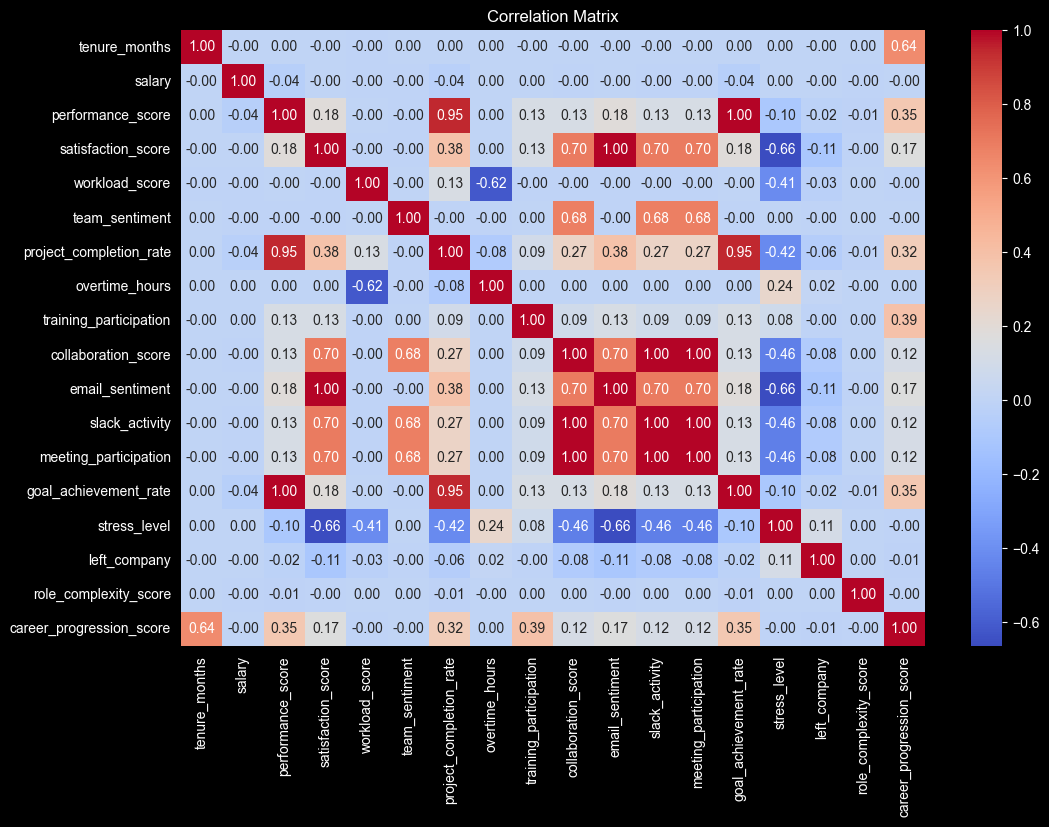

In [35]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [36]:
df_clean.head()

,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,recent_feedback,project_completion_rate,...,technical_skills,soft_skills,email_sentiment,slack_activity,meeting_participation,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score
0,Mid,R&D,169,79704.579059,0.632482,0.623746,0.758117,0.662335,Close to home and good shift time given Slow i...,0.524187,...,"[REST APIs, Python (Pandas, NumPy, SciPy), Lin...","[Communication, Creativity, Teamwork, Conflict...",0.632891,0.492131,0.492131,0.632482,0.908992,False,0.2,1.000000
1,Manager,R&D,54,29694.288831,0.538587,0.982556,0.788416,0.934661,HSBC Software Development Pune India Review Gr...,0.558206,...,"[Network Security, GCP, dbt, Express.js, Docke...","[Conflict Resolution, Problem Solving, Creativ...",1.000000,0.981394,0.981394,0.538587,0.363321,False,0.2,1.000000
2,Entry,HR,1,62208.470185,0.624656,0.767200,0.697617,0.888559,Great opportunity for growth if you drink the ...,0.566849,...,"[Node.js, dbt, CI/CD Pipelines, Angular, Ruby ...","[Problem Solving, Critical Thinking, Teamwork,...",0.758005,0.701138,0.701138,0.624656,0.664378,True,0.2,0.836495
3,Manager,R&D,31,236066.567114,0.959320,0.185888,0.493143,0.732189,Fabulous people and broad opportunities The ch...,0.767456,...,"[Ruby on Rails, GraphQL, Python (Django, Flask...","[Emotional Intelligence, Leadership, Conflict ...",0.202517,0.339626,0.339626,0.959320,1.000000,False,0.2,1.000000
4,Mid,R&D,131,37306.328156,0.677305,0.566706,0.567230,0.817545,"The harder you work, the faster you climb. I w...",0.597235,...,"[Vue.js, XGBoost, ETL/ELT Pipelines, Linux/Uni...","[Critical Thinking, Communication, Creativity,...",0.559722,0.565582,0.565582,0.677305,0.723049,False,0.2,1.000000


Correlation Analysis Results:
No variable is overly correlated with the target variable left_company. The highest value is .11.
Many of the variables show very high correlation.
- Correlation scores of 1 between collaboration_score, slack_activity & meeting_participation. After review these variables are duplicates of each other. Will likely keep one and remove the other 2.
- Higher stress levels show a negative correlation with scores like satisfaction, project completion rate, and communication variables.
- Performance_score and goal_achievement_rate are also duplicates of each other.

In [37]:
df_clean = df_clean.drop(columns=["slack_activity", "meeting_participation", "performance_score"])
df_clean.head()

,job_level,department,tenure_months,salary,satisfaction_score,workload_score,team_sentiment,recent_feedback,project_completion_rate,overtime_hours,training_participation,collaboration_score,technical_skills,soft_skills,email_sentiment,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score
0,Mid,R&D,169,79704.579059,0.623746,0.758117,0.662335,Close to home and good shift time given Slow i...,0.524187,0.00000,0.044373,0.492131,"[REST APIs, Python (Pandas, NumPy, SciPy), Lin...","[Communication, Creativity, Teamwork, Conflict...",0.632891,0.632482,0.908992,False,0.2,1.000000
1,Manager,R&D,54,29694.288831,0.982556,0.788416,0.934661,HSBC Software Development Pune India Review Gr...,0.558206,0.00000,0.314858,0.981394,"[Network Security, GCP, dbt, Express.js, Docke...","[Conflict Resolution, Problem Solving, Creativ...",1.000000,0.538587,0.363321,False,0.2,1.000000
2,Entry,HR,1,62208.470185,0.767200,0.697617,0.888559,Great opportunity for growth if you drink the ...,0.566849,0.00000,0.744900,0.701138,"[Node.js, dbt, CI/CD Pipelines, Angular, Ruby ...","[Problem Solving, Critical Thinking, Teamwork,...",0.758005,0.624656,0.664378,True,0.2,0.836495
3,Manager,R&D,31,236066.567114,0.185888,0.493143,0.732189,Fabulous people and broad opportunities The ch...,0.767456,9.59168,0.298170,0.339626,"[Ruby on Rails, GraphQL, Python (Django, Flask...","[Emotional Intelligence, Leadership, Conflict ...",0.202517,0.959320,1.000000,False,0.2,1.000000
4,Mid,R&D,131,37306.328156,0.566706,0.567230,0.817545,"The harder you work, the faster you climb. I w...",0.597235,0.00000,0.134719,0.565582,"[Vue.js, XGBoost, ETL/ELT Pipelines, Linux/Uni...","[Critical Thinking, Communication, Creativity,...",0.559722,0.677305,0.723049,False,0.2,1.000000


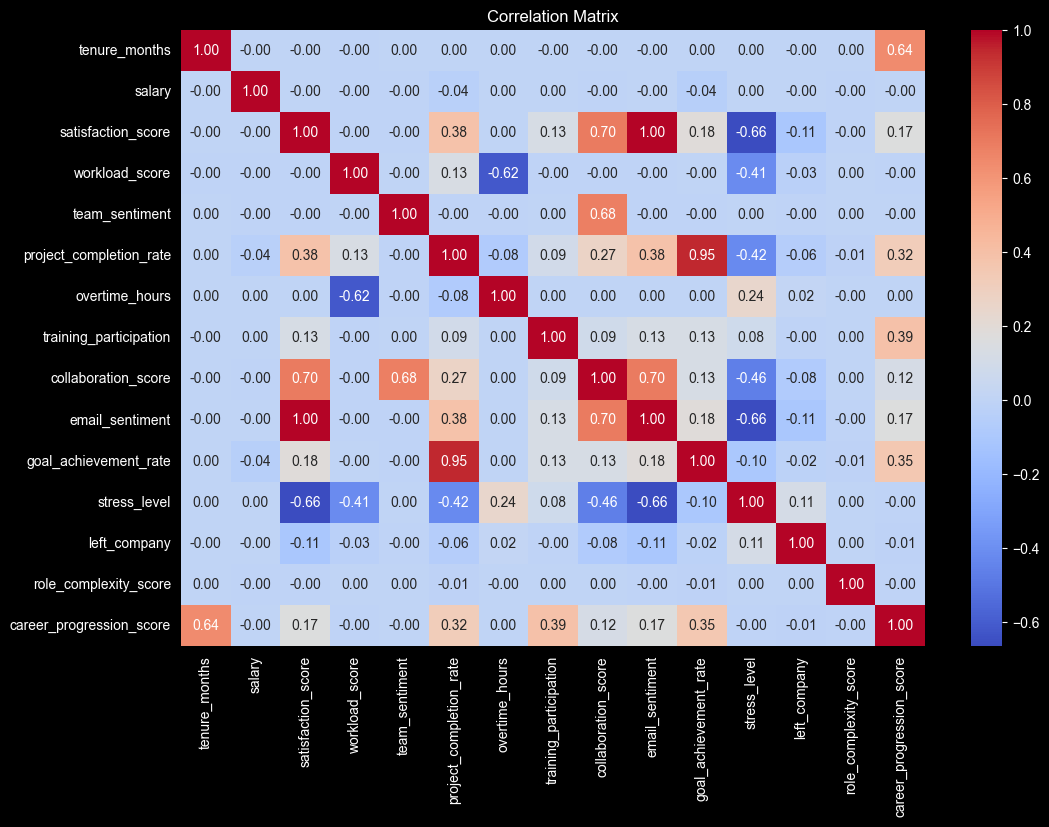

In [38]:
corr_df = df_clean.copy()
corr_df["left_company"] = corr_df["left_company"].astype(int)
corr = corr_df.select_dtypes(include="number").corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### We can see after some duplicate variable removal there is much less correlation. Email sentiment and satisfaction_score are similar but not duplicates. Same with goal_achievement_rate and project_completion_rate. We will keep them in.

In [39]:
group_df = df_clean.groupby("left_company").mean(numeric_only=True).T
group_df.columns = ["Stayed", "Left"]
group_df["diff"] = group_df["Left"] - group_df["Stayed"]
group_df.sort_values("diff")

,Stayed,Left,diff
salary,84568.141290,84550.366687,-17.774604
tenure_months,70.400620,70.331853,-0.068767
email_sentiment,0.601663,0.534122,-0.067542
satisfaction_score,0.601152,0.533823,-0.067329
collaboration_score,0.482480,0.450587,-0.031894
project_completion_rate,0.601109,0.581142,-0.019967
workload_score,0.603572,0.589266,-0.014306
goal_achievement_rate,0.694350,0.686208,-0.008142
career_progression_score,0.842385,0.838044,-0.004342
training_participation,0.279530,0.278880,-0.000649


When we look at this table showing the difference in left_company based on means of other numeric variables per group, we see the most impactful ones seem to be overtime_hours, satisfaction_score, stress_level

Text(0.5, 1.0, 'Attrition by Satisfaction Score')

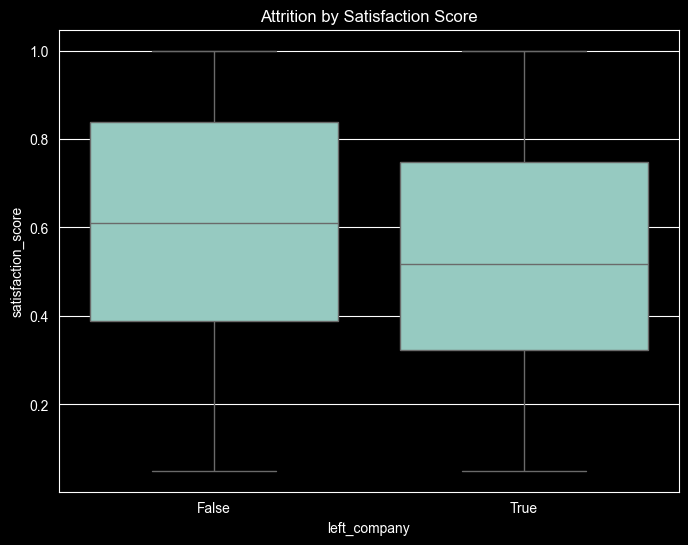

In [40]:
plt.figure(figsize=(8,6))

sns.boxplot(data=df_clean, x="left_company", y="satisfaction_score")
plt.title("Attrition by Satisfaction Score")

Text(0.5, 1.0, 'Attrition by Overtime Hours')

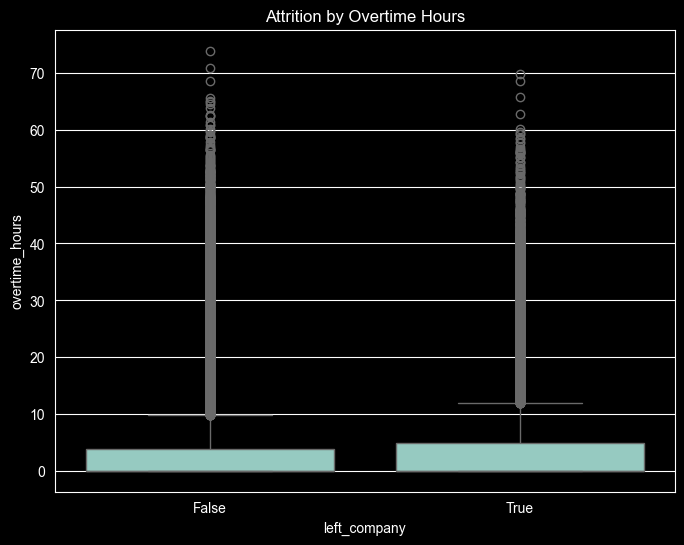

In [41]:
plt.figure(figsize=(8,6))

sns.boxplot(data=df_clean, x="left_company", y="overtime_hours")
plt.title("Attrition by Overtime Hours")


Text(0.5, 1.0, 'Attrition by Stress Level')

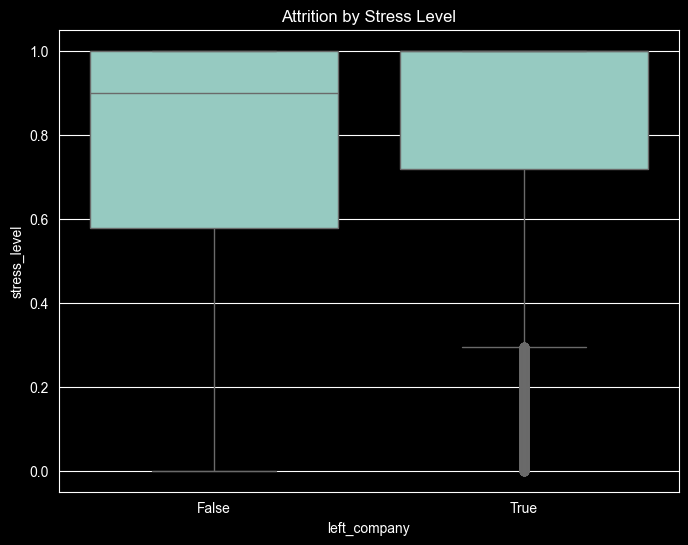

In [42]:
plt.figure(figsize=(8,6))

sns.boxplot(data=df_clean, x="left_company", y="stress_level")
plt.title("Attrition by Stress Level")


In [43]:
numeric_df = df_clean.select_dtypes(include="number")
numeric_df.skew().sort_values()

stress_level               -1.067622
career_progression_score   -0.924113
team_sentiment             -0.466471
project_completion_rate    -0.353207
workload_score             -0.284178
goal_achievement_rate      -0.272181
satisfaction_score         -0.105482
email_sentiment            -0.100779
collaboration_score         0.329739
tenure_months               0.459229
salary                      0.744652
training_participation      1.094593
overtime_hours              2.466777
role_complexity_score       8.120073
dtype: float64

Text(0.5, 1.0, 'Stress Level')

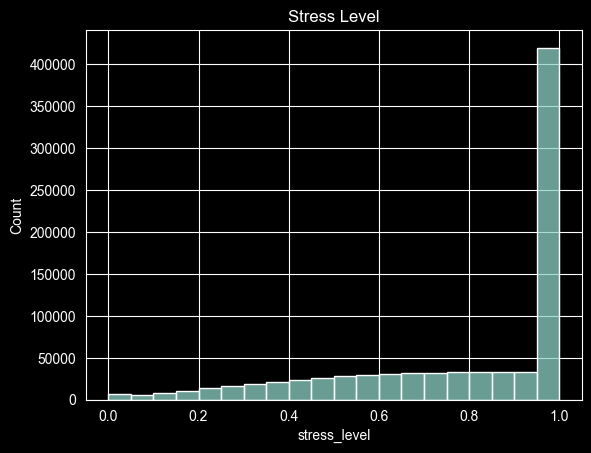

In [44]:
sns.histplot(data=df_clean, x="stress_level", bins=20)
plt.title("Stress Level")

<Axes: xlabel='role_complexity_score', ylabel='Count'>

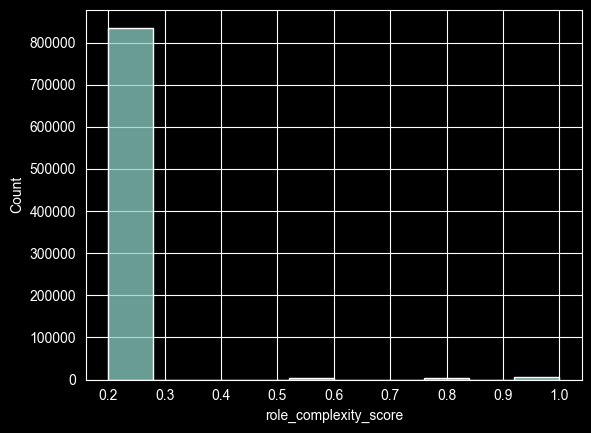

In [45]:
sns.histplot(data=df_clean, x="role_complexity_score", bins=10)

Text(0.5, 1.0, 'Overtime Hours')

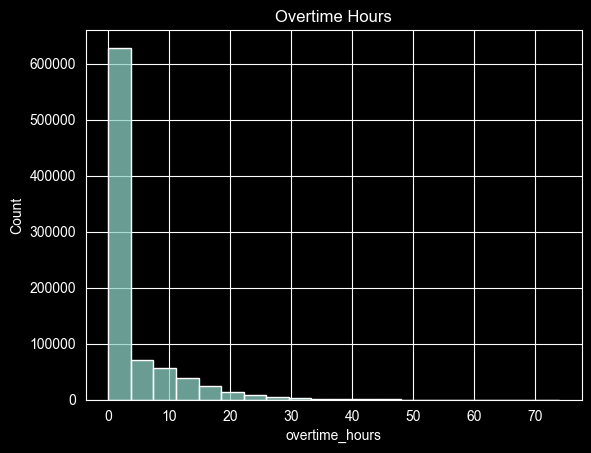

In [46]:
sns.histplot(data=df_clean, x="overtime_hours", bins=20)
plt.title("Overtime Hours")


In [47]:
df_clean["role_complexity_score"].describe()

count    849999.000000
mean          0.210859
std           0.085018
min           0.200000
25%           0.200000
50%           0.200000
75%           0.200000
max           1.000000
Name: role_complexity_score, dtype: float64

In [48]:
# Most of the values here are .20, then there are a few variations. This is why the skew is so high.
df_clean["role_complexity_score"].value_counts()

role_complexity_score
0.200000    831760
1.000000      6355
0.800000      4421
0.600000      3656
0.210033         1
             ...  
0.204872         1
0.216244         1
0.209222         1
0.200517         1
0.208731         1
Name: count, Length: 3811, dtype: int64

## Categorical Variable EDA

In [49]:
cat_df = df_clean.select_dtypes(exclude="number")

In [50]:
cat_df

,job_level,department,recent_feedback,technical_skills,soft_skills,left_company
0,Mid,R&D,Close to home and good shift time given Slow i...,"[REST APIs, Python (Pandas, NumPy, SciPy), Lin...","[Communication, Creativity, Teamwork, Conflict...",False
1,Manager,R&D,HSBC Software Development Pune India Review Gr...,"[Network Security, GCP, dbt, Express.js, Docke...","[Conflict Resolution, Problem Solving, Creativ...",False
2,Entry,HR,Great opportunity for growth if you drink the ...,"[Node.js, dbt, CI/CD Pipelines, Angular, Ruby ...","[Problem Solving, Critical Thinking, Teamwork,...",True
3,Manager,R&D,Fabulous people and broad opportunities The ch...,"[Ruby on Rails, GraphQL, Python (Django, Flask...","[Emotional Intelligence, Leadership, Conflict ...",False
4,Mid,R&D,"The harder you work, the faster you climb. I w...","[Vue.js, XGBoost, ETL/ELT Pipelines, Linux/Uni...","[Critical Thinking, Communication, Creativity,...",False
...,...,...,...,...,...,...
849994,Mid,R&D,Kein Schatten ohne Sonne We do not review who ...,"[AWS, Data Warehousing (Snowflake, BigQuery, R...","[Teamwork, Critical Thinking, Leadership, Ment...",False
849995,Entry,Sales & Marketing,Overall quite positive experience with a few a...,"[Site Reliability Engineering (SRE), AWS, Apac...","[Adaptability, Mentorship, Critical Thinking, ...",True
849996,Senior,Operations,Nice environment and friendly colleagues Fast-...,"[Go, Statistics, Webpack, Data Modeling]","[Teamwork, Conflict Resolution, Mentorship, Le...",False
849997,Mid,Sales & Marketing,"structured, many events to participate in, can...","[Rust, Webpack, Express.js, SQL]","[Creativity, Time Management, Leadership, Comm...",True


In [51]:
job_level_attrition = df_clean.groupby("job_level")["left_company"].mean()
job_level_attrition

job_level
Entry      0.287103
Lead       0.283372
Manager    0.289380
Mid        0.284822
Senior     0.281641
Name: left_company, dtype: float64

In [52]:
department_attrition = df_clean.groupby("department")["left_company"].mean()
department_attrition

department
Accounting           0.281639
Analytics            0.285344
Customer Service     0.285174
Executive            0.313697
Finance              0.288067
Grocery              0.284959
HR                   0.288135
IT                   0.287199
Legal                0.281383
Operations           0.286165
Procurement          0.286110
Production           0.286808
R&D                  0.285823
Sales & Marketing    0.283271
Store Management     0.298507
Unknown              0.283825
Name: left_company, dtype: float64

Text(0.5, 1.0, 'Job Level Attrition')

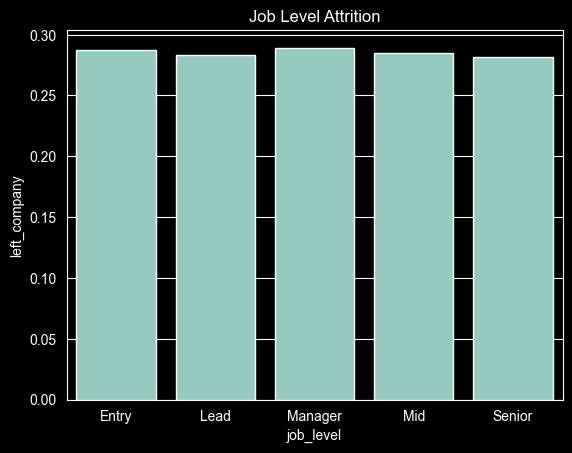

In [53]:
sns.barplot(data=job_level_attrition)
plt.title("Job Level Attrition")


Text(0.5, 1.0, 'Department Attribution')

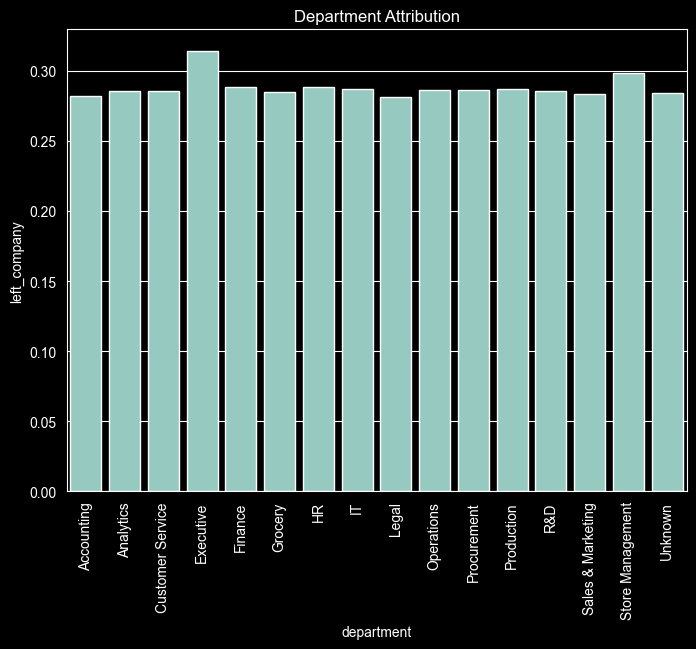

In [54]:
plt.figure(figsize=(8,6))
sns.barplot(data=department_attrition)
plt.xticks(rotation=90)
plt.title("Department Attribution")

## It looks like we have not much variation across job_level or department. There is a bit of a jump for Executive and Store Management roles in the department category.

In [55]:
job_level_attrition = df_clean.groupby("job_level")["salary"].mean()
job_level_attrition

job_level
Entry      84707.805782
Lead       83814.953595
Manager    84599.645580
Mid        84560.186078
Senior     84531.960766
Name: salary, dtype: float64

In [56]:
department_attrition = df_clean.groupby("department")["stress_level"].mean()
department_attrition

department
Accounting           0.788662
Analytics            0.791670
Customer Service     0.792920
Executive            0.804872
Finance              0.788701
Grocery              0.790616
HR                   0.791979
IT                   0.789891
Legal                0.792739
Operations           0.791046
Procurement          0.791866
Production           0.792134
R&D                  0.790722
Sales & Marketing    0.791050
Store Management     0.800861
Unknown              0.791811
Name: stress_level, dtype: float64

In [57]:
department_attrition = df_clean.groupby("department")["satisfaction_score"].mean()
department_attrition

department
Accounting           0.577892
Analytics            0.581107
Customer Service     0.580819
Executive            0.585458
Finance              0.582023
Grocery              0.581966
HR                   0.582517
IT                   0.583519
Legal                0.585463
Operations           0.582350
Procurement          0.581183
Production           0.580012
R&D                  0.581636
Sales & Marketing    0.581926
Store Management     0.565710
Unknown              0.589502
Name: satisfaction_score, dtype: float64

In [58]:
department_attrition = df_clean.groupby("department")["workload_score"].mean()
department_attrition

department
Accounting           0.596547
Analytics            0.598507
Customer Service     0.598339
Executive            0.596365
Finance              0.601591
Grocery              0.600007
HR                   0.598406
IT                   0.598867
Legal                0.596686
Operations           0.599690
Procurement          0.599114
Production           0.601362
R&D                  0.599602
Sales & Marketing    0.599711
Store Management     0.605475
Unknown              0.595217
Name: workload_score, dtype: float64

# Feature Engineering

The plan is to work on sentiment analysis on recent feedback, and to see if we can create a usable variable from technical and soft_skills lists.

In [59]:
df_clean.head()

,job_level,department,tenure_months,salary,satisfaction_score,workload_score,team_sentiment,recent_feedback,project_completion_rate,overtime_hours,training_participation,collaboration_score,technical_skills,soft_skills,email_sentiment,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score
0,Mid,R&D,169,79704.579059,0.623746,0.758117,0.662335,Close to home and good shift time given Slow i...,0.524187,0.00000,0.044373,0.492131,"[REST APIs, Python (Pandas, NumPy, SciPy), Lin...","[Communication, Creativity, Teamwork, Conflict...",0.632891,0.632482,0.908992,False,0.2,1.000000
1,Manager,R&D,54,29694.288831,0.982556,0.788416,0.934661,HSBC Software Development Pune India Review Gr...,0.558206,0.00000,0.314858,0.981394,"[Network Security, GCP, dbt, Express.js, Docke...","[Conflict Resolution, Problem Solving, Creativ...",1.000000,0.538587,0.363321,False,0.2,1.000000
2,Entry,HR,1,62208.470185,0.767200,0.697617,0.888559,Great opportunity for growth if you drink the ...,0.566849,0.00000,0.744900,0.701138,"[Node.js, dbt, CI/CD Pipelines, Angular, Ruby ...","[Problem Solving, Critical Thinking, Teamwork,...",0.758005,0.624656,0.664378,True,0.2,0.836495
3,Manager,R&D,31,236066.567114,0.185888,0.493143,0.732189,Fabulous people and broad opportunities The ch...,0.767456,9.59168,0.298170,0.339626,"[Ruby on Rails, GraphQL, Python (Django, Flask...","[Emotional Intelligence, Leadership, Conflict ...",0.202517,0.959320,1.000000,False,0.2,1.000000
4,Mid,R&D,131,37306.328156,0.566706,0.567230,0.817545,"The harder you work, the faster you climb. I w...",0.597235,0.00000,0.134719,0.565582,"[Vue.js, XGBoost, ETL/ELT Pipelines, Linux/Uni...","[Critical Thinking, Communication, Creativity,...",0.559722,0.677305,0.723049,False,0.2,1.000000


In [60]:
df_clean["technical_skills"].head()

0    [REST APIs, Python (Pandas, NumPy, SciPy), Lin...
1    [Network Security, GCP, dbt, Express.js, Docke...
2    [Node.js, dbt, CI/CD Pipelines, Angular, Ruby ...
3    [Ruby on Rails, GraphQL, Python (Django, Flask...
4    [Vue.js, XGBoost, ETL/ELT Pipelines, Linux/Uni...
Name: technical_skills, dtype: object

In [61]:
df_clean["tech_skill_count"] = df_clean["technical_skills"].apply(len)
df_clean.head()

,job_level,department,tenure_months,salary,satisfaction_score,workload_score,team_sentiment,recent_feedback,project_completion_rate,overtime_hours,...,collaboration_score,technical_skills,soft_skills,email_sentiment,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score,tech_skill_count
0,Mid,R&D,169,79704.579059,0.623746,0.758117,0.662335,Close to home and good shift time given Slow i...,0.524187,0.00000,...,0.492131,"[REST APIs, Python (Pandas, NumPy, SciPy), Lin...","[Communication, Creativity, Teamwork, Conflict...",0.632891,0.632482,0.908992,False,0.2,1.000000,8
1,Manager,R&D,54,29694.288831,0.982556,0.788416,0.934661,HSBC Software Development Pune India Review Gr...,0.558206,0.00000,...,0.981394,"[Network Security, GCP, dbt, Express.js, Docke...","[Conflict Resolution, Problem Solving, Creativ...",1.000000,0.538587,0.363321,False,0.2,1.000000,6
2,Entry,HR,1,62208.470185,0.767200,0.697617,0.888559,Great opportunity for growth if you drink the ...,0.566849,0.00000,...,0.701138,"[Node.js, dbt, CI/CD Pipelines, Angular, Ruby ...","[Problem Solving, Critical Thinking, Teamwork,...",0.758005,0.624656,0.664378,True,0.2,0.836495,9
3,Manager,R&D,31,236066.567114,0.185888,0.493143,0.732189,Fabulous people and broad opportunities The ch...,0.767456,9.59168,...,0.339626,"[Ruby on Rails, GraphQL, Python (Django, Flask...","[Emotional Intelligence, Leadership, Conflict ...",0.202517,0.959320,1.000000,False,0.2,1.000000,4
4,Mid,R&D,131,37306.328156,0.566706,0.567230,0.817545,"The harder you work, the faster you climb. I w...",0.597235,0.00000,...,0.565582,"[Vue.js, XGBoost, ETL/ELT Pipelines, Linux/Uni...","[Critical Thinking, Communication, Creativity,...",0.559722,0.677305,0.723049,False,0.2,1.000000,4


In [62]:
df_clean["tech_skill_count"].value_counts().sort_index()

tech_skill_count
4    141492
5    141806
6    142199
7    141026
8    141891
9    141585
Name: count, dtype: int64

In [63]:
from collections import Counter

skill_count = Counter()

for skills in df_clean["technical_skills"]:
    skill_count.update(skills)

skill_count.most_common(20)

[('HTML5', 113341),
 ('Docker', 113336),
 ('SQL', 113332),
 ('Deep Learning (TensorFlow, PyTorch)', 113247),
 ('Data Warehousing (Snowflake, BigQuery, Redshift)', 113137),
 ('Java (Spring Boot)', 112987),
 ('Apache Kafka', 112986),
 ('A/B Testing', 112986),
 ('Python (Pandas, NumPy, SciPy)', 112962),
 ('CI/CD Pipelines', 112957),
 ('Site Reliability Engineering (SRE)', 112949),
 ('CSS3', 112947),
 ('GCP', 112911),
 ('Webpack', 112909),
 ('Machine Learning Theory', 112907),
 ('Network Security', 112862),
 ('Computer Vision', 112859),
 ('XGBoost', 112857),
 ('C# (.NET)', 112844),
 ('ETL/ELT Pipelines', 112837)]

It seems like technical skills holds zero variation between number of skills and rates of skills. I don't think we will get much out of this variable, so I will remove it before modeling. In a non synthetic dataset it may hold more weight, but for this one it will not give much to the prediction.

In [64]:
df_clean["soft_skills"].head()

0    [Communication, Creativity, Teamwork, Conflict...
1    [Conflict Resolution, Problem Solving, Creativ...
2    [Problem Solving, Critical Thinking, Teamwork,...
3    [Emotional Intelligence, Leadership, Conflict ...
4    [Critical Thinking, Communication, Creativity,...
Name: soft_skills, dtype: object

In [65]:
df_clean["soft_skill_count"] = df_clean["soft_skills"].apply(len)
df_clean.head()

,job_level,department,tenure_months,salary,satisfaction_score,workload_score,team_sentiment,recent_feedback,project_completion_rate,overtime_hours,...,technical_skills,soft_skills,email_sentiment,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score,tech_skill_count,soft_skill_count
0,Mid,R&D,169,79704.579059,0.623746,0.758117,0.662335,Close to home and good shift time given Slow i...,0.524187,0.00000,...,"[REST APIs, Python (Pandas, NumPy, SciPy), Lin...","[Communication, Creativity, Teamwork, Conflict...",0.632891,0.632482,0.908992,False,0.2,1.000000,8,7
1,Manager,R&D,54,29694.288831,0.982556,0.788416,0.934661,HSBC Software Development Pune India Review Gr...,0.558206,0.00000,...,"[Network Security, GCP, dbt, Express.js, Docke...","[Conflict Resolution, Problem Solving, Creativ...",1.000000,0.538587,0.363321,False,0.2,1.000000,6,5
2,Entry,HR,1,62208.470185,0.767200,0.697617,0.888559,Great opportunity for growth if you drink the ...,0.566849,0.00000,...,"[Node.js, dbt, CI/CD Pipelines, Angular, Ruby ...","[Problem Solving, Critical Thinking, Teamwork,...",0.758005,0.624656,0.664378,True,0.2,0.836495,9,6
3,Manager,R&D,31,236066.567114,0.185888,0.493143,0.732189,Fabulous people and broad opportunities The ch...,0.767456,9.59168,...,"[Ruby on Rails, GraphQL, Python (Django, Flask...","[Emotional Intelligence, Leadership, Conflict ...",0.202517,0.959320,1.000000,False,0.2,1.000000,4,5
4,Mid,R&D,131,37306.328156,0.566706,0.567230,0.817545,"The harder you work, the faster you climb. I w...",0.597235,0.00000,...,"[Vue.js, XGBoost, ETL/ELT Pipelines, Linux/Uni...","[Critical Thinking, Communication, Creativity,...",0.559722,0.677305,0.723049,False,0.2,1.000000,4,5


In [66]:
df_clean["soft_skill_count"].value_counts().sort_index()

soft_skill_count
3    169496
4    170022
5    170067
6    169999
7    170415
Name: count, dtype: int64

In [67]:

skill_count = Counter()

for skills in df_clean["soft_skills"]:
    skill_count.update(skills)

skill_count.most_common(20)

[('Problem Solving', 387189),
 ('Emotional Intelligence', 387090),
 ('Conflict Resolution', 386827),
 ('Communication', 386671),
 ('Creativity', 386565),
 ('Mentorship', 386510),
 ('Critical Thinking', 386466),
 ('Time Management', 386300),
 ('Teamwork', 386242),
 ('Leadership', 386046),
 ('Adaptability', 385904)]

We run into the same problem we had with technical skills here in soft skills. I believe this variable should also be remove as it holds no variation across groups.

In [68]:
df_clean["recent_feedback"].head()

0    Close to home and good shift time given Slow i...
1    HSBC Software Development Pune India Review Gr...
2    Great opportunity for growth if you drink the ...
3    Fabulous people and broad opportunities The ch...
4    The harder you work, the faster you climb. I w...
Name: recent_feedback, dtype: str

In [69]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [70]:
sentiment_scores = []

for feedback in df_clean["recent_feedback"]:
    scores = analyzer.polarity_scores(feedback)
    sentiment_scores.append(scores["compound"])

df_clean["feedback_sentiment"] = sentiment_scores

In [71]:
df_clean.head()

,job_level,department,tenure_months,salary,satisfaction_score,workload_score,team_sentiment,recent_feedback,project_completion_rate,overtime_hours,...,soft_skills,email_sentiment,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score,tech_skill_count,soft_skill_count,feedback_sentiment
0,Mid,R&D,169,79704.579059,0.623746,0.758117,0.662335,Close to home and good shift time given Slow i...,0.524187,0.00000,...,"[Communication, Creativity, Teamwork, Conflict...",0.632891,0.632482,0.908992,False,0.2,1.000000,8,7,0.7351
1,Manager,R&D,54,29694.288831,0.982556,0.788416,0.934661,HSBC Software Development Pune India Review Gr...,0.558206,0.00000,...,"[Conflict Resolution, Problem Solving, Creativ...",1.000000,0.538587,0.363321,False,0.2,1.000000,6,5,0.9509
2,Entry,HR,1,62208.470185,0.767200,0.697617,0.888559,Great opportunity for growth if you drink the ...,0.566849,0.00000,...,"[Problem Solving, Critical Thinking, Teamwork,...",0.758005,0.624656,0.664378,True,0.2,0.836495,9,6,0.8999
3,Manager,R&D,31,236066.567114,0.185888,0.493143,0.732189,Fabulous people and broad opportunities The ch...,0.767456,9.59168,...,"[Emotional Intelligence, Leadership, Conflict ...",0.202517,0.959320,1.000000,False,0.2,1.000000,4,5,0.7184
4,Mid,R&D,131,37306.328156,0.566706,0.567230,0.817545,"The harder you work, the faster you climb. I w...",0.597235,0.00000,...,"[Critical Thinking, Communication, Creativity,...",0.559722,0.677305,0.723049,False,0.2,1.000000,4,5,-0.3404


In [72]:
df_clean["feedback_sentiment"].describe()

count    849999.000000
mean          0.465638
std           0.546672
min          -0.941000
25%           0.128000
50%           0.700300
75%           0.899900
max           0.989300
Name: feedback_sentiment, dtype: float64

In [73]:
df_clean.groupby("left_company")["feedback_sentiment"].mean()

left_company
False    0.484245
True     0.419034
Name: feedback_sentiment, dtype: float64

Text(0.5, 1.0, 'Feedback Sentiment')

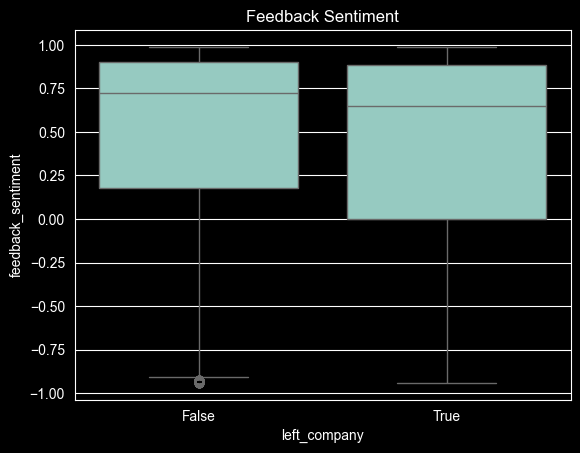

In [74]:
sns.boxplot(data=df_clean, x="left_company", y="feedback_sentiment")
plt.title("Feedback Sentiment")

### The sentiment analysis on recent feedback looks like a success though! There is variation between the two groups, with the people who leave the company reporting a lower feedback_sentiment score.

Lets drop some of the columns we are not using from this feature engineering analysis.

In [75]:
df_clean.head()

,job_level,department,tenure_months,salary,satisfaction_score,workload_score,team_sentiment,recent_feedback,project_completion_rate,overtime_hours,...,soft_skills,email_sentiment,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score,tech_skill_count,soft_skill_count,feedback_sentiment
0,Mid,R&D,169,79704.579059,0.623746,0.758117,0.662335,Close to home and good shift time given Slow i...,0.524187,0.00000,...,"[Communication, Creativity, Teamwork, Conflict...",0.632891,0.632482,0.908992,False,0.2,1.000000,8,7,0.7351
1,Manager,R&D,54,29694.288831,0.982556,0.788416,0.934661,HSBC Software Development Pune India Review Gr...,0.558206,0.00000,...,"[Conflict Resolution, Problem Solving, Creativ...",1.000000,0.538587,0.363321,False,0.2,1.000000,6,5,0.9509
2,Entry,HR,1,62208.470185,0.767200,0.697617,0.888559,Great opportunity for growth if you drink the ...,0.566849,0.00000,...,"[Problem Solving, Critical Thinking, Teamwork,...",0.758005,0.624656,0.664378,True,0.2,0.836495,9,6,0.8999
3,Manager,R&D,31,236066.567114,0.185888,0.493143,0.732189,Fabulous people and broad opportunities The ch...,0.767456,9.59168,...,"[Emotional Intelligence, Leadership, Conflict ...",0.202517,0.959320,1.000000,False,0.2,1.000000,4,5,0.7184
4,Mid,R&D,131,37306.328156,0.566706,0.567230,0.817545,"The harder you work, the faster you climb. I w...",0.597235,0.00000,...,"[Critical Thinking, Communication, Creativity,...",0.559722,0.677305,0.723049,False,0.2,1.000000,4,5,-0.3404


In [76]:
df_clean = df_clean.drop(columns=["recent_feedback", "technical_skills", "tech_skill_count", "soft_skill_count", "soft_skills"])

In [77]:
df_clean.head()

,job_level,department,tenure_months,salary,satisfaction_score,workload_score,team_sentiment,project_completion_rate,overtime_hours,training_participation,collaboration_score,email_sentiment,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score,feedback_sentiment
0,Mid,R&D,169,79704.579059,0.623746,0.758117,0.662335,0.524187,0.00000,0.044373,0.492131,0.632891,0.632482,0.908992,False,0.2,1.000000,0.7351
1,Manager,R&D,54,29694.288831,0.982556,0.788416,0.934661,0.558206,0.00000,0.314858,0.981394,1.000000,0.538587,0.363321,False,0.2,1.000000,0.9509
2,Entry,HR,1,62208.470185,0.767200,0.697617,0.888559,0.566849,0.00000,0.744900,0.701138,0.758005,0.624656,0.664378,True,0.2,0.836495,0.8999
3,Manager,R&D,31,236066.567114,0.185888,0.493143,0.732189,0.767456,9.59168,0.298170,0.339626,0.202517,0.959320,1.000000,False,0.2,1.000000,0.7184
4,Mid,R&D,131,37306.328156,0.566706,0.567230,0.817545,0.597235,0.00000,0.134719,0.565582,0.559722,0.677305,0.723049,False,0.2,1.000000,-0.3404


<Axes: xlabel='job_level', ylabel='salary'>

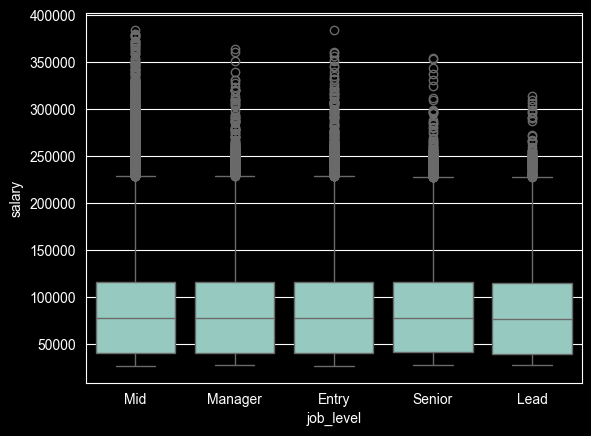

In [78]:
sns.boxplot(data=df_clean, x="job_level", y="salary")

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'R&D'),
  Text(1, 0, 'HR'),
  Text(2, 0, 'Grocery'),
  Text(3, 0, 'Procurement'),
  Text(4, 0, 'Sales & Marketing'),
  Text(5, 0, 'IT'),
  Text(6, 0, 'Operations'),
  Text(7, 0, 'Legal'),
  Text(8, 0, 'Analytics'),
  Text(9, 0, 'Customer Service'),
  Text(10, 0, 'Production'),
  Text(11, 0, 'Finance'),
  Text(12, 0, 'Executive'),
  Text(13, 0, 'Unknown'),
  Text(14, 0, 'Store Management'),
  Text(15, 0, 'Accounting')])

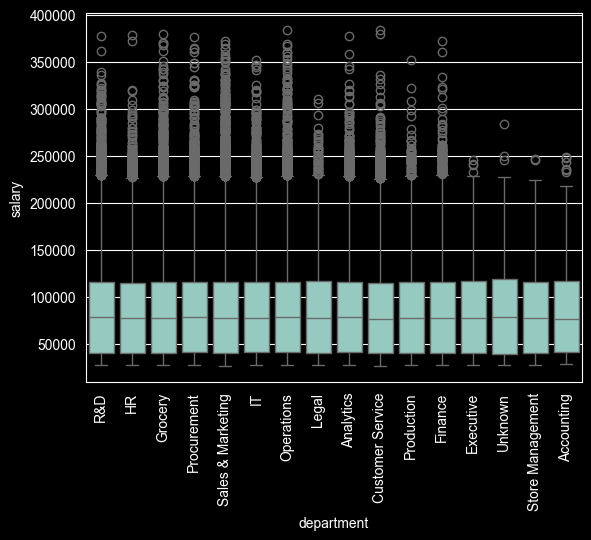

In [79]:
sns.boxplot(data=df_clean, x="department", y="salary")
plt.xticks(rotation=90)

In [80]:
salary_mean = df_clean["salary"].mean()
salary_mean

np.float64(84563.06975061278)

In [81]:
df_clean["underpaid_overtime"] = ((df_clean["salary"] < salary_mean) & (df_clean["overtime_hours"] > 0))
df_clean.head()

,job_level,department,tenure_months,salary,satisfaction_score,workload_score,team_sentiment,project_completion_rate,overtime_hours,training_participation,collaboration_score,email_sentiment,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score,feedback_sentiment,underpaid_overtime
0,Mid,R&D,169,79704.579059,0.623746,0.758117,0.662335,0.524187,0.00000,0.044373,0.492131,0.632891,0.632482,0.908992,False,0.2,1.000000,0.7351,False
1,Manager,R&D,54,29694.288831,0.982556,0.788416,0.934661,0.558206,0.00000,0.314858,0.981394,1.000000,0.538587,0.363321,False,0.2,1.000000,0.9509,False
2,Entry,HR,1,62208.470185,0.767200,0.697617,0.888559,0.566849,0.00000,0.744900,0.701138,0.758005,0.624656,0.664378,True,0.2,0.836495,0.8999,False
3,Manager,R&D,31,236066.567114,0.185888,0.493143,0.732189,0.767456,9.59168,0.298170,0.339626,0.202517,0.959320,1.000000,False,0.2,1.000000,0.7184,False
4,Mid,R&D,131,37306.328156,0.566706,0.567230,0.817545,0.597235,0.00000,0.134719,0.565582,0.559722,0.677305,0.723049,False,0.2,1.000000,-0.3404,False


In [82]:
df_clean["underpaid_overtime"].value_counts()

underpaid_overtime
False    704984
True     145015
Name: count, dtype: int64

Text(0.5, 1.0, 'Underpaid Overtime')

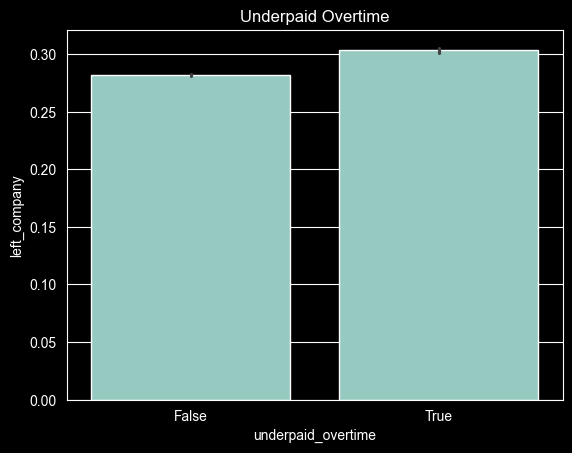

In [83]:
sns.barplot(data=df_clean, x="underpaid_overtime", y="left_company")
plt.title("Underpaid Overtime")

In [84]:
df_clean["burnout_indicator_score"] = (df_clean["stress_level"] + df_clean["workload_score"] - df_clean["satisfaction_score"])
df_clean.head()

,job_level,department,tenure_months,salary,satisfaction_score,workload_score,team_sentiment,project_completion_rate,overtime_hours,training_participation,collaboration_score,email_sentiment,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score,feedback_sentiment,underpaid_overtime,burnout_indicator_score
0,Mid,R&D,169,79704.579059,0.623746,0.758117,0.662335,0.524187,0.00000,0.044373,0.492131,0.632891,0.632482,0.908992,False,0.2,1.000000,0.7351,False,1.043363
1,Manager,R&D,54,29694.288831,0.982556,0.788416,0.934661,0.558206,0.00000,0.314858,0.981394,1.000000,0.538587,0.363321,False,0.2,1.000000,0.9509,False,0.169181
2,Entry,HR,1,62208.470185,0.767200,0.697617,0.888559,0.566849,0.00000,0.744900,0.701138,0.758005,0.624656,0.664378,True,0.2,0.836495,0.8999,False,0.594795
3,Manager,R&D,31,236066.567114,0.185888,0.493143,0.732189,0.767456,9.59168,0.298170,0.339626,0.202517,0.959320,1.000000,False,0.2,1.000000,0.7184,False,1.307255
4,Mid,R&D,131,37306.328156,0.566706,0.567230,0.817545,0.597235,0.00000,0.134719,0.565582,0.559722,0.677305,0.723049,False,0.2,1.000000,-0.3404,False,0.723572


<Axes: xlabel='burnout_indicator_score', ylabel='Count'>

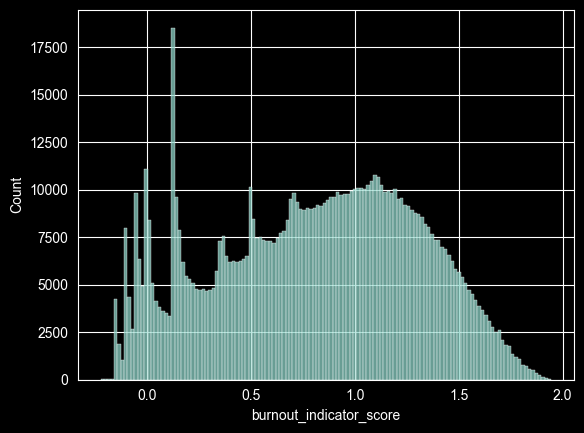

In [85]:
sns.histplot(data=df_clean, x="burnout_indicator_score")

<Axes: xlabel='left_company', ylabel='burnout_indicator_score'>

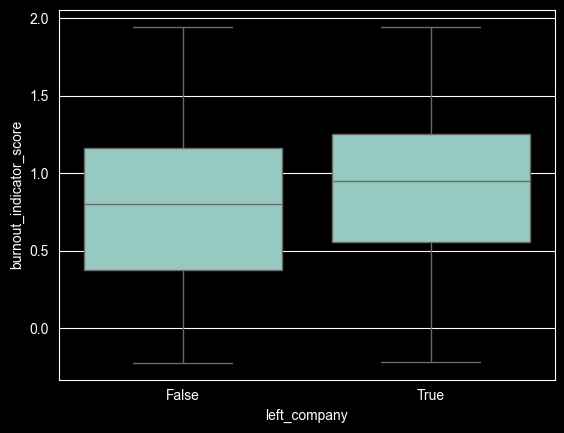

In [86]:
sns.boxplot(data=df_clean, x="left_company", y="burnout_indicator_score")

In [87]:
df_clean.groupby("left_company")["burnout_indicator_score"].mean()

left_company
False    0.774276
True     0.894564
Name: burnout_indicator_score, dtype: float64

In [88]:
df_clean["new_employee"] = df_clean["tenure_months"] < 12
df_clean.head()

,job_level,department,tenure_months,salary,satisfaction_score,workload_score,team_sentiment,project_completion_rate,overtime_hours,training_participation,...,email_sentiment,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score,feedback_sentiment,underpaid_overtime,burnout_indicator_score,new_employee
0,Mid,R&D,169,79704.579059,0.623746,0.758117,0.662335,0.524187,0.00000,0.044373,...,0.632891,0.632482,0.908992,False,0.2,1.000000,0.7351,False,1.043363,False
1,Manager,R&D,54,29694.288831,0.982556,0.788416,0.934661,0.558206,0.00000,0.314858,...,1.000000,0.538587,0.363321,False,0.2,1.000000,0.9509,False,0.169181,False
2,Entry,HR,1,62208.470185,0.767200,0.697617,0.888559,0.566849,0.00000,0.744900,...,0.758005,0.624656,0.664378,True,0.2,0.836495,0.8999,False,0.594795,True
3,Manager,R&D,31,236066.567114,0.185888,0.493143,0.732189,0.767456,9.59168,0.298170,...,0.202517,0.959320,1.000000,False,0.2,1.000000,0.7184,False,1.307255,False
4,Mid,R&D,131,37306.328156,0.566706,0.567230,0.817545,0.597235,0.00000,0.134719,...,0.559722,0.677305,0.723049,False,0.2,1.000000,-0.3404,False,0.723572,False


Text(0.5, 1.0, 'New Employee')

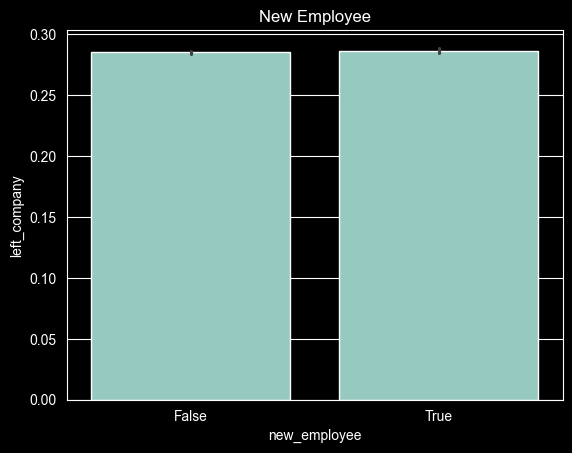

In [89]:
sns.barplot(data=df_clean, x="new_employee", y="left_company")
plt.title("New Employee")

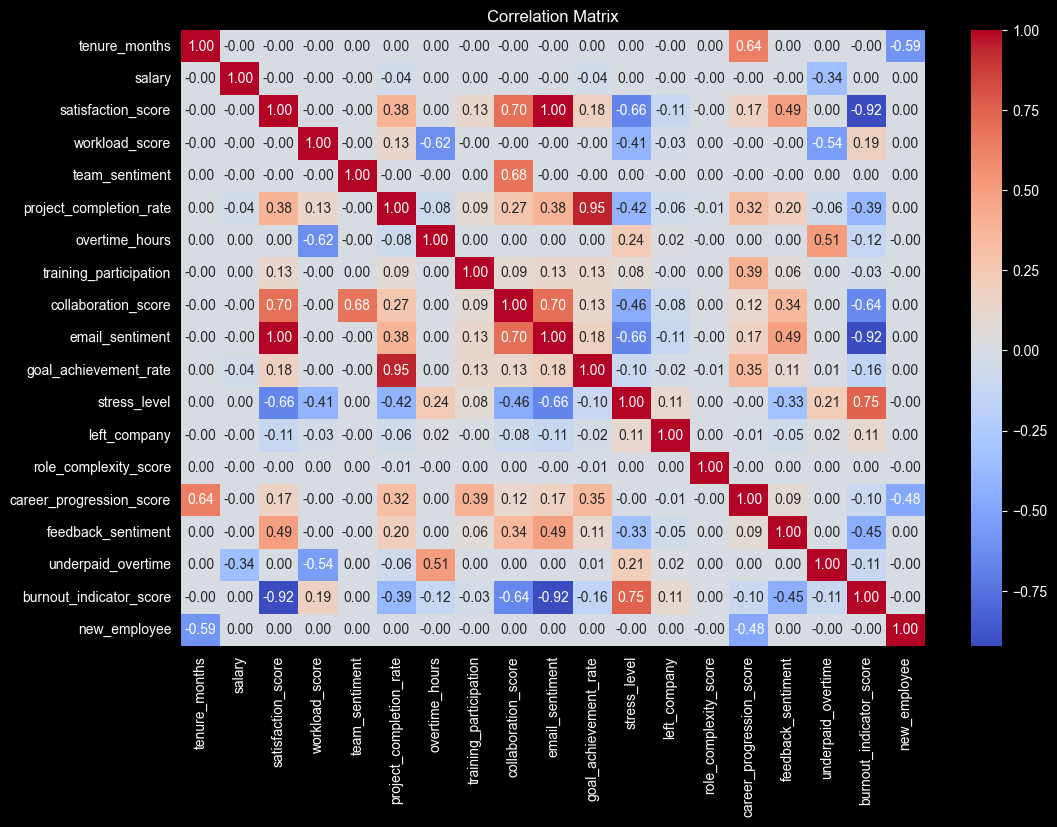

In [90]:
corr_df = df_clean.copy()
corr_df["left_company"] = corr_df["left_company"].astype(int)
corr_df["underpaid_overtime"] = corr_df["underpaid_overtime"].astype(int)
corr_df["new_employee"] = corr_df["new_employee"].astype(int)
corr = corr_df.select_dtypes(include="number").corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [91]:
df_clean.to_csv("employee_attrition_clean.csv", index=False)